**Task 3: Customer Churn Prediction**

**Objective**

The objective of this project is to identify bank customers who are likely to leave the bank (churn).

**Problem Statement**

Customer retention is important for banks because acquiring new customers is generally more expensive than retaining existing ones.

This project analyzes customer information and builds a machine learning model to predict customer churn. Feature importance analysis is also performed to identify factors that influence customer retention.

In [3]:
# ==========================================
# Import Required Libraries
# ==========================================

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

sns.set_style("whitegrid")

**Dataset Understanding**

The Churn Modelling dataset contains customer information such as:

- Credit Score
- Geography
- Gender
- Age
- Balance
- Number of Products
- Estimated Salary

Target Variable:
- Exited

Exited = 1 means customer left the bank.
Exited = 0 means customer stayed.

**Load Dataset**

In [4]:
df = pd.read_csv('Churn_Modelling.csv')
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


**Basic Information**

In [5]:
# Basic Dataset Information

print("Dataset Shape:")
print(df.shape)

print("\nColumn Names:")
print(df.columns)

print("\nDataset Information:")
df.info()

Dataset Shape:
(10000, 14)

Column Names:
Index(['RowNumber', 'CustomerId', 'Surname', 'CreditScore', 'Geography',
       'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard',
       'IsActiveMember', 'EstimatedSalary', 'Exited'],
      dtype='object')

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  

**Data Cleaning and Preparation**

The dataset was checked for missing values using the `isnull().sum()` function.

No missing values were found in any column, therefore no imputation or missing value handling was required.

To prepare the data for machine learning, unnecessary columns such as RowNumber, CustomerId, and Surname were removed.


In [6]:
# Check Missing Values

print(df.isnull().sum())

RowNumber          0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64


In [7]:
# Remove Unnecessary Columns

df.drop(
    ['RowNumber', 'CustomerId', 'Surname'],
    axis=1,
    inplace=True
)

df.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


**Encoding Categorical Features**

Machine learning models require numerical input.

Categorical features such as Geography and Gender are encoded into numerical values.

In [8]:
# Encode Gender

label_encoder = LabelEncoder()

df['Gender'] = label_encoder.fit_transform(
    df['Gender']
)

In [9]:
# One-Hot Encoding for Geography

df = pd.get_dummies(
    df,
    columns=['Geography'],
    drop_first=True
)

df.head()

,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_Germany,Geography_Spain
0,619,0,42,2,0.00,1,1,1,101348.88,1,0,0
1,608,0,41,1,83807.86,1,0,1,112542.58,0,0,1
2,502,0,42,8,159660.80,3,1,0,113931.57,1,0,0
3,699,0,39,1,0.00,2,0,0,93826.63,0,0,0
4,850,0,43,2,125510.82,1,1,1,79084.10,0,0,1


**Exploratory Data Analysis (EDA)**

The following visualizations help understand customer churn patterns.

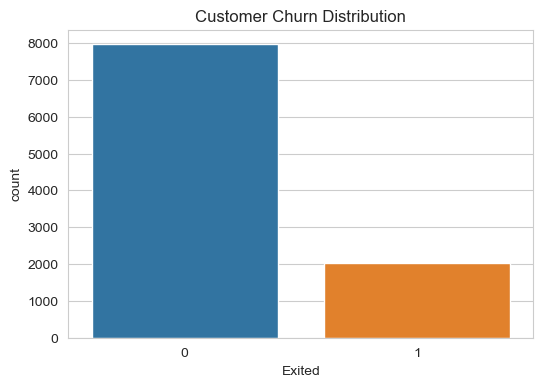

In [10]:
# Churn Distribution

plt.figure(figsize=(6,4))

sns.countplot(
    data=df,
    x='Exited'
)

plt.title("Customer Churn Distribution")

plt.show()

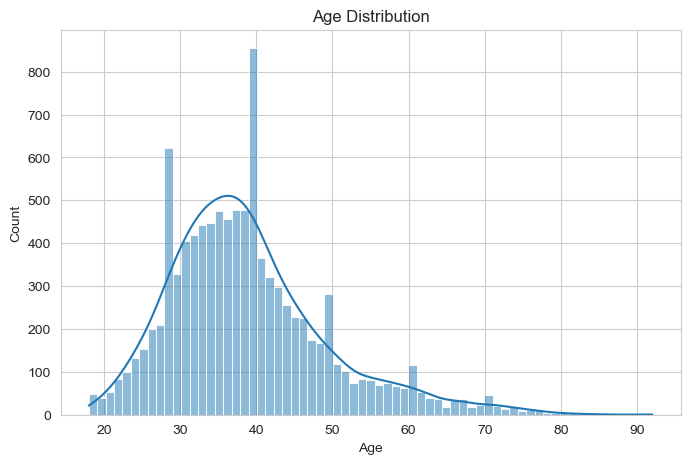

In [11]:
# Age Distribution
plt.figure(figsize=(8,5))

sns.histplot(
    df['Age'],
    kde=True
)

plt.title("Age Distribution")

plt.show()

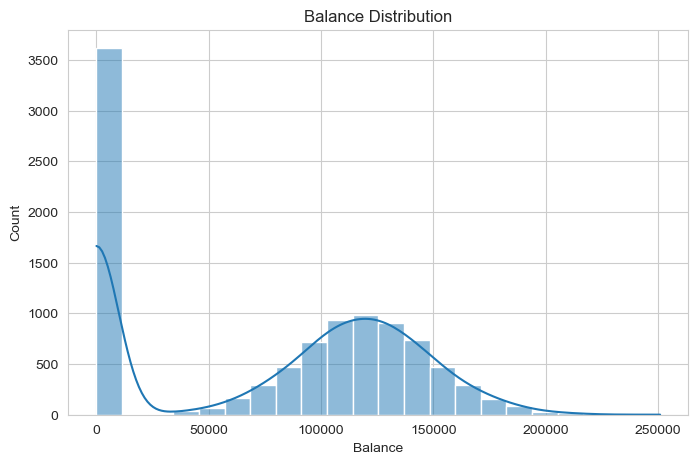

In [12]:
# Balance Distribution

plt.figure(figsize=(8,5))

sns.histplot(
    df['Balance'],
    kde=True
)

plt.title("Balance Distribution")

plt.show()

**Model Training and Testing**

A Random Forest Classifier is used to predict customer churn.

In [13]:
# Separate Features and Target

X = df.drop('Exited', axis=1)

y = df['Exited']

In [14]:
# Split Dataset

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

In [15]:
# Train Random Forest Model

model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

**Model Evaluation**

Model performance is evaluated using:

- Accuracy Score
- Confusion Matrix
- Classification Report

In [16]:
# Accuracy Score
accuracy = accuracy_score(
    y_test,
    y_pred
)

print("Accuracy:", accuracy)

Accuracy: 0.866


In [17]:
# Confusion Matrix

cm = confusion_matrix(
    y_test,
    y_pred
)

print(cm)

[[1552   55]
 [ 213  180]]


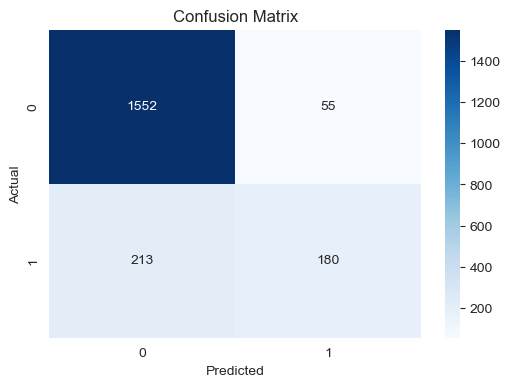

In [18]:
# Visualize Confusion Matrix

plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Confusion Matrix")

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [19]:
# Classification Report


print(
    classification_report(
        y_test,
        y_pred
    )
)

              precision    recall  f1-score   support

           0       0.88      0.97      0.92      1607
           1       0.77      0.46      0.57       393

    accuracy                           0.87      2000
   macro avg       0.82      0.71      0.75      2000
weighted avg       0.86      0.87      0.85      2000



**Feature Importance Analysis**

Feature importance helps identify which factors have the greatest impact on customer churn.

In [20]:
# Feature Importance
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

print(importance)

              Feature  Importance
2                 Age    0.239783
8     EstimatedSalary    0.146638
0         CreditScore    0.144214
4             Balance    0.138613
5       NumOfProducts    0.130255
3              Tenure    0.082427
7      IsActiveMember    0.041110
9   Geography_Germany    0.025711
1              Gender    0.019258
6           HasCrCard    0.018722
10    Geography_Spain    0.013268


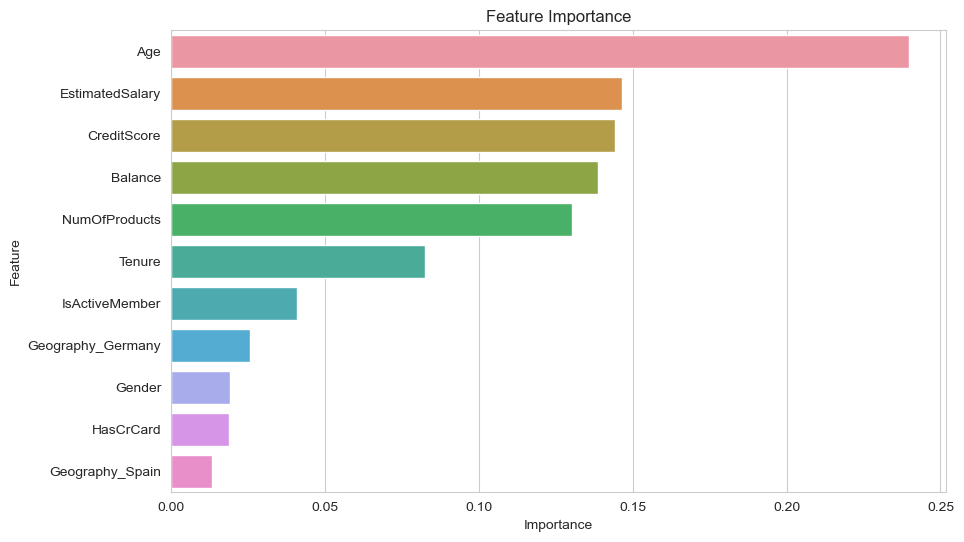

In [21]:
# Visualize Feature Importance

plt.figure(figsize=(10,6))

sns.barplot(
    data=importance,
    x='Importance',
    y='Feature'
)

plt.title("Feature Importance")

plt.show()

**Conclusion**

The customer churn dataset was successfully prepared and analyzed. No missing values were found in the dataset, and irrelevant identifier columns were removed before model training.

Categorical features such as Gender and Geography were encoded to make them suitable for machine learning algorithms.

A Random Forest Classifier was trained to predict customer churn and achieved an accuracy of 86.6%.

The confusion matrix showed that the model performed very well in identifying customers who stayed with the bank. However, some churned customers were still missed, as indicated by the lower recall for the churn class.

Feature importance analysis helped identify the factors that have the greatest influence on customer churn behavior.

Overall, the model demonstrated strong predictive performance and provided useful insights into customer retention.